In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [27]:
#Load Dataset
url = ('https://github.com/GeethaGunasekaran1/Dataset_rep/raw/refs/heads/main/social_media_engagement_5000.csv')
df = pd.read_csv(url)

In [28]:
#check & Convert data types
if 'posted_at' in df.columns:
  df['posted_at'] = pd.to_datetime(df['posted_at'])
elif 'post_date' in df.columns:
  df['post_date'] =pd.to_datetime(df['post_date'])
print(df.dtypes)

user_id                      int64
age                        float64
gender                      object
country                     object
post_id                      int64
post_type                   object
post_category               object
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                   object
hashtags                    object
engagement_rate            float64
dtype: object


/tmp/ipykernel_552/1923326095.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['posted_at'] = pd.to_datetime(df['posted_at'])


In [29]:
#Detect Missing Values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [30]:
#Missing values
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols: df[col] = df[col].fillna(df[col].median())
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols : df[col].fillna(df[col].mode()[0])
print("Missing values after filling:")
print(df.isnull().sum())


Missing values after filling:
user_id               0
age                   0
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes                 0
comments              0
shares                0
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [31]:
#Remove duplicate
df.drop_duplicates(inplace=True)

In [32]:
#Date column
if 'post_date' in df.columns : df['post_date']=pd.to_datetime(df['post_date'], errors='coerce')

In [33]:
#Standardize Categories
if 'genter' in df.columns:
  df['gender'] = df['gender'].astype(str).str.title().strip()
  if 'sentiment' in df.columns:
    df['sentiment'] = df['sentiment'].asty(str).str.lower().str.strip()

In [34]:
#correct unrealistic values
#Likes , comments, shares
for metric in ['likes', 'comments', 'share', 'impressions', 'watch_time_sec']:
  if metric in df.columns:
    df[metric] = df[metric].apply(lambda x: max(0, x))

In [35]:
#Function
if 'hashtags' in df.columns:
    df['hashtag_count'] =  df['hashtags'].astype(str).apply(lambda x: len(x.split()) if x!='nan' else 0)
print("---Hashtag Count Added Successfully!---")
df[['hashtags', 'hashtag_count']].head()

---Hashtag Count Added Successfully!---


,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1


In [36]:
#View dataset Structure
print("---First 5 Rows(head)---")
display(df.head())

---First 5 Rows(head)---


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


In [37]:
print("---Last 5 Rows(tail)---")
display(df.tail())

---Last 5 Rows(tail)---


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


In [38]:
print("\n---Dataset shape(Rows, Columns)---")
print(df.shape)


---Dataset shape(Rows, Columns)---
(5000, 20)


In [39]:
print("\n---column names---")
print(df.columns.tolist())


---column names---
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'hashtag_count']


In [40]:
print("\n---Dataset information---")
print(df.dtypes)


---Dataset information---
user_id                      int64
age                        float64
gender                      object
country                     object
post_id                      int64
post_type                   object
post_category               object
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                   object
hashtags                    object
engagement_rate            float64
hashtag_count                int64
dtype: object


In [41]:
print("\n---summary statistics(categorical)---")
display(df.describe(include=['object']))


---summary statistics(categorical)---


,gender,country,post_type,post_category,device_type,sentiment,hashtags
count,4850,5000,5000,5000,5000,4850,5000
unique,3,10,4,8,3,3,761
top,Male,India,reel,fitness,mobile,positive,#tech
freq,1699,535,1283,675,1684,2363,201


In [42]:
print("\n---Categorical Analysis---")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
  print(f"\nvalue count for '{col}':")
  print(df[col].value_counts())
  print(f"Unique of unique values in '{col}':", df[col].unique())
  print(f"number of unique values in '{col}':", df[col].nunique())


---Categorical Analysis---

value count for 'gender':
gender
Male      1699
Other     1581
Female    1570
Name: count, dtype: int64
Unique of unique values in 'gender': ['Female' 'Male' 'Other' nan]
number of unique values in 'gender': 3

value count for 'country':
country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64
Unique of unique values in 'country': ['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']
number of unique values in 'country': 10

value count for 'post_type':
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64
Unique of unique values in 'post_type': ['image' 'reel' 'text' 'video']
number of unique values in 'post_type': 4

value count for 'post_category':
post_category
fitness      675
tech         665
music        635
education    631
lifestyle    

In [43]:
print("\n---Correlation Mzatrix---")
numeric_df = df.select_dtypes(include=['float64', 'int64'])
Correlation_matrix = numeric_df.corr()
display(Correlation_matrix)


---Correlation Mzatrix---


,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,0.007344
likes,0.025811,-0.036322,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,0.008802
engagement_rate,-0.004282,0.008039,0.010139,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.005319


In [44]:
print("\n---Groupby summaries---")
if 'post_type' in df.columns and 'likes' in df.columns:
  print("\nAverage Likes by Post Type:")
  display(df.groupby('post_type') ['likes'].mean())



---Groupby summaries---

Average Likes by Post Type:


,likes
post_type,
image,10104.865277
reel,10037.802416
text,10100.148193
video,10188.600000


In [45]:
if 'country' in df.columns and 'impression_count' in df.columns:
  print("\nAverage impressions by Country:")
  display(df.groupby('country') ['impression_count'].mean())


Average impressions by Country:


,impression_count
country,
Australia,48346.383367
Brazil,49193.174603
Canada,48703.150097
France,51727.673387
Germany,48605.406122
India,52462.386916
Japan,49616.135593
UAE,48928.413519
UK,51119.393509


In [46]:
if 'sentiment' in df.columns and 'engagement_rate' in df.columns:
  print("\nAverage Engagement Rate by Sentiment:")
  display(df.groupby('sentiment') ['engagement_rate'].mean())


Average Engagement Rate by Sentiment:


,engagement_rate
sentiment,
negative,1.038486
neutral,0.991170
positive,0.954800


In [47]:
categories = pd.DataFrame({'post_type':
df['post_type'].unique(), 'cat_id':
range(1, len(df['post_type'].unique()) + 1)})
df = pd.merge(df, categories, on='post_type', how='left')
df['engagement_score'] = df['likes'] + (df['comments'] * 2) + (df['shares'] +
3)
df['log_likes'] = np.log1p(df['likes'])
print("---Avg Engagement by post type---")
display(df.groupby('post_type')
[['likes', 'engagement_score']].mean())
print("\n---Avg Engagement by Sentiment---")
display(df.groupby('sentiment')
[['likes', 'engagement_score']].mean())

---Avg Engagement by post type---


,likes,engagement_score
post_type,,
image,10104.865277,14177.626303
reel,10037.802416,14031.218628
text,10100.148193,14115.349799
video,10188.600000,14146.754286



---Avg Engagement by Sentiment---


,likes,engagement_score
sentiment,,
negative,10208.096875,14250.593750
neutral,9923.194499,13979.567780
positive,10156.926788,14126.610664


In [48]:
#columns to analyze
target_cols = ['likes', 'comments', 'shares', 'watch_time_sec', 'watch_time', 'engagement_rate', 'followers' ]
stats_cols = [col for col in target_cols if col in df.columns]
#Computing Descriptive Statistics
stats_summary = pd.DataFrame({
    'Mean': df[stats_cols].mean(),
    'Median': df[stats_cols].median(),
    'Mode': df[stats_cols].mode().iloc[0],
    'Std Dev':df[stats_cols].std(),
    'Variance':df[stats_cols].var(),
    '25th Percentile':
df[stats_cols].quantile(0.25),
    '50th Percentile':
df[stats_cols].quantile(0.50),
    '70th Percentile':
df[stats_cols].quantile(0.70),
    'skewness':df[stats_cols].skew(),
    'kurtosis':df[stats_cols].kurt()
})
display(stats_summary.T)

,likes,comments,shares,watch_time_sec,engagement_rate
Mean,1.010700e+04,1502.039800,1002.910600,4.014503e+03,0.964356
Median,1.010550e+04,1497.000000,1012.000000,4.034500e+03,0.253896
Mode,1.010550e+04,1497.000000,1012.000000,9.160000e+02,0.006363
Std Dev,5.702293e+03,856.393312,570.855200,2.308096e+03,5.318029
Variance,3.251615e+07,733409.504917,325875.659340,5.327309e+06,28.281435
25th Percentile,5.235000e+03,792.000000,511.000000,2.017750e+03,0.145781
50th Percentile,1.010550e+04,1497.000000,1012.000000,4.034500e+03,0.253896
70th Percentile,1.396410e+04,2080.000000,1391.300000,5.623600e+03,0.418583
skewness,-6.893617e-03,0.003802,-0.014654,-1.819627e-02,18.781271
kurtosis,-1.149992e+00,-1.144375,-1.146857,-1.195652e+00,482.991739


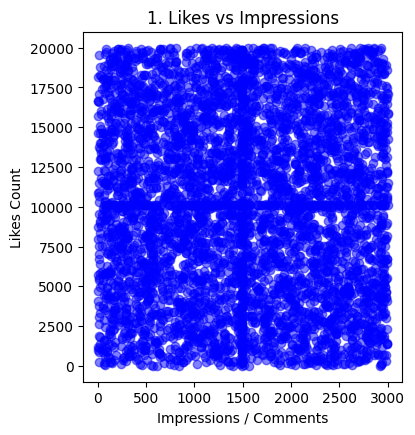

In [49]:
#Scatter Polt
plt.figure(figsize=(14,10))
plt.subplot(2, 3, 1)
x_val = df['impressions'] if 'impressions' in df.columns else df['comments']
plt.scatter(x_val, df['likes'], alpha=0.5, color='blue')
plt.title('1. Likes vs Impressions')
plt.xlabel('Impressions / Comments')
plt.ylabel('Likes Count')
plt.show()

(array([18993., 19083., 19174., 19266., 19358., 19448., 19539., 19631.,
        19723.]),
 [Text(18993.0, 0, '2022-01'),
  Text(19083.0, 0, '2022-04'),
  Text(19174.0, 0, '2022-07'),
  Text(19266.0, 0, '2022-10'),
  Text(19358.0, 0, '2023-01'),
  Text(19448.0, 0, '2023-04'),
  Text(19539.0, 0, '2023-07'),
  Text(19631.0, 0, '2023-10'),
  Text(19723.0, 0, '2024-01')])

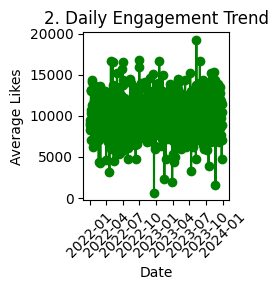

In [50]:
#Line chart
plt.subplot(2, 3, 2)
if 'posted_at' in df.columns:
    daily_data = df.groupby(df['posted_at'].dt.date)['likes'].mean()
    plt.plot(daily_data.index, daily_data.values, color='green', marker='o')
plt.title('2. Daily Engagement Trend')
plt.xlabel('Date')
plt.ylabel('Average Likes')
plt
plt.xticks(rotation=45)

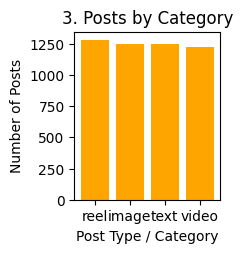

In [51]:
#Bar Chart
plt.subplot(2, 3, 3)
if 'post_type' in df.columns:
    counts = df['post_type'].value_counts()
    plt.bar(counts.index, counts.values, color='orange')
plt.title('3. Posts by Category')
plt.xlabel('Post Type / Category')
plt.ylabel('Number of Posts')
plt.show()

Text(0.5, 1.0, '4. Gender Distribution')

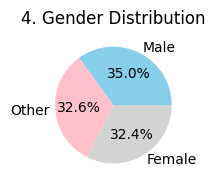

In [52]:
#Pie Chart
plt.subplot(2, 3, 4)
if 'gender' in df.columns:
    gender_counts = df['gender'].value_counts()
    plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=['skyblue', 'pink', 'lightgray'])
plt.title('4. Gender Distribution')

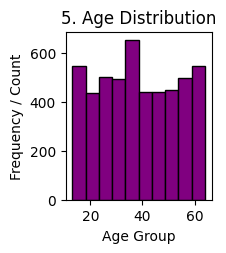

In [53]:
#Histogram
plt.subplot(2, 3, 5)
if 'age' in df.columns:
    plt.hist(df['age'].dropna(), bins=10, color='purple', edgecolor='black')
plt.title('5. Age Distribution')
plt.xlabel('Age Group')
plt.ylabel('Frequency / Count')
plt.show()

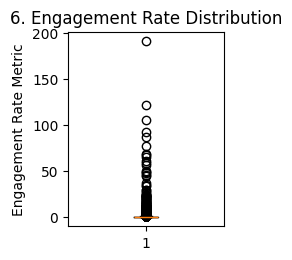

In [54]:
#Box Plot
plt.subplot(2, 3, 6)
if 'engagement_rate' in df.columns:
    plt.boxplot(df['engagement_rate'].dropna())
plt.title('6. Engagement Rate Distribution')
plt.ylabel('Engagement Rate Metric')

plt.tight_layout()
plt.show()

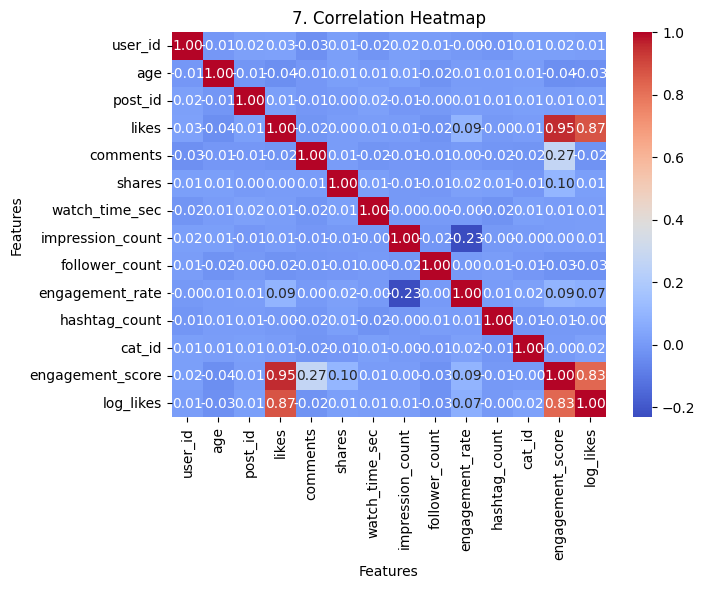

In [55]:
#Seaborn Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('7. Correlation Heatmap')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

In [56]:
#Plotly Interactive Chart
if 'post_type' in df.columns:
    fig = px.scatter(
        df,
        x='likes',
        y='comments',
        color='post_type',
        title='8. Interactive Scatter: Likes vs Comments',
        labels={'likes': 'Total Likes', 'comments': 'Total Comments'}
    )
    fig.show()

In [57]:
# Final Insights Print
print("\n--- FINAL INSIGHTS ---")
if 'post_type' in df.columns and 'likes' in df.columns:
    print("1. Best Post Type (Highest Avg Likes):", df.groupby('post_type')['likes'].mean().idxmax())
if 'country' in df.columns and 'engagement_rate' in df.columns:
    print("2. Top Country (Highest Engagement):", df.groupby('country')['engagement_rate'].mean().idxmax())


--- FINAL INSIGHTS ---
1. Best Post Type (Highest Avg Likes): video
2. Top Country (Highest Engagement): Brazil
